# SVGD

Implements Algorithm 1 "Bayesian Inference via Variational Gradient Descent" from [1]

[1] Liu, Qiang, and Dilin Wang. "Stein variational gradient descent: A general purpose bayesian inference algorithm." Advances in neural information processing systems 29 (2016).

## Changes:

- Fixed bug, accidentally has attraction instead of repulsion!
- Exploring only updating the expensive grad log prob occasionally --> this method allows us to use the empirical estimate for a bit (weighted sum between particles) -> might need to increase particles a bit to do this?
- Next Plan: Approximate the repulsive term (e.g. with a 'mean field' version???)

In [1]:
import jax.numpy as np
import jax.scipy.stats.multivariate_normal as mvn
import matplotlib.pyplot as plt
import numpy as standard_np
from jax import value_and_grad, grad, vmap


In [2]:
def plotdata(data,color='black'):
    #plt.hexbin(data[:,0],data[:,1],gridsize=40,extent=(0,5,0,5))
    plotx = standard_np.linspace(0, 5, 40)
    ploty = standard_np.linspace(0, 5, 40)
    plotX, plotY = standard_np.meshgrid(plotx, ploty)
    #[prob(np.array([x,y])) for x,y in zip(X,Y)]
    plotZ = prob(standard_np.array([plotX.flatten(),plotY.flatten()]).T).reshape(len(plotx),len(ploty))
    plt.contour(plotX, plotY, plotZ)
    plt.scatter(data[:,0],data[:,1],1,color=color)
    plt.xlim([0,5])
    plt.ylim([0,5])

def prob(x):
    return (mvn.pdf(x,np.array([2,2]),np.array([[1,-0.8],[-0.8,1]]))+mvn.pdf(x,np.array([3.5,4]),np.array([[0.5,0],[0,0.5]])))/2

def logprob(x):
    return np.log(prob(x))

#EQ KERNEL
def k(x,xprime):
    return 0.1*np.exp(-np.sum((x[:,None]-xprime[None,:])**2/1,2))
def ksingle(x,xprime):
    return 0.1*np.exp(-np.sum((x-xprime)**2/1))

#EXPONENTIAL KERNEL
#def k(x,xprime):
#    return 10*np.exp(-np.sum(np.abs(x[:,None]-xprime[None,:])/0.1,2))
#def ksingle(x,xprime):
#    return 10*np.exp(-np.sum(np.abs(x-xprime)/0.1))

In [29]:
#this list-comprehension takes 2.29s vs 56.8ms for the vmap
#[grad(logprob)(p_i) for p_i in p]

p = standard_np.random.rand(50,2)*5
#p = p[np.argsort(p[:,0]),:]
for it in range(500):
    K = k(p,p)
    g = vmap(grad(logprob),0)(p)

    #compute the kernel between all particles...
    gk = vmap(lambda p2: vmap(grad(lambda p1: ksingle(p1,p2)))(p))(p)
    #p+=(K@g+np.sum(gk,1))*0.04 #with the repulsion term
    p+=(g+np.sum(gk,1))*0.02 #messing with optimising them individually.

    #if we just want the "ML" version
    #p+=(K@g)*0.04  #no repulsion (just ML)

In [40]:
#this list-comprehension takes 2.29s vs 56.8ms for the vmap
#[grad(logprob)(p_i) for p_i in p]

p = standard_np.random.rand(10,2)*5
#p = p[np.argsort(p[:,0]),:]
for it in range(500):
    
    if it%10==0:
        oldp = p
        g = vmap(grad(logprob),0)(oldp)
        
    K = k(p,oldp)
    #compute the kernel between all particles...
    
    gk = vmap(lambda p2: vmap(grad(lambda p1: ksingle(p1,p2)))(p))(oldp)
    p+=(K@g+np.sum(gk,1))*0.04 #with the repulsion term
    #p+=(g+np.sum(gk,1))*0.02 #messing with optimising them individually.

    
    #if we just want the "ML" version
    #p+=(K@g)*0.04  #no repulsion (just ML)

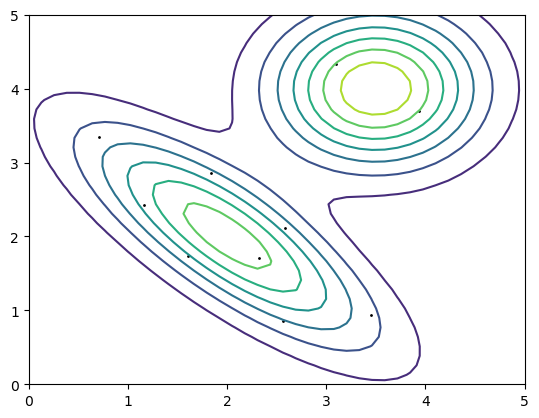

In [41]:
plotdata(p)

In [42]:
for N in [10,50,250,1250]:
    print(N)
    p = standard_np.random.rand(N,2)*5
    %timeit -n 1 -r 1 k(p,p)
    %timeit -n 1 -r 1 vmap(grad(logprob),0)(p)
    %timeit -n 1 -r 1 vmap(lambda p2: vmap(grad(lambda p1: ksingle(p1,p2)))(p))(p)
    %timeit -n 1 -r 1 (K@g+np.sum(gk,1))*0.04

10
890 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
64.8 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
11.2 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
157 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
50
185 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
46.4 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
8.95 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
129 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
250
946 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
39.8 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
8.91 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
130 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
1250
24.5 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
49.5 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
13.1 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
323 μs ± 0 ns pe

# What does the repulsion term look like?

With the RBF kernel... it's a bit odd: The repulsion actually reduces when you get really close? Is this desirable?

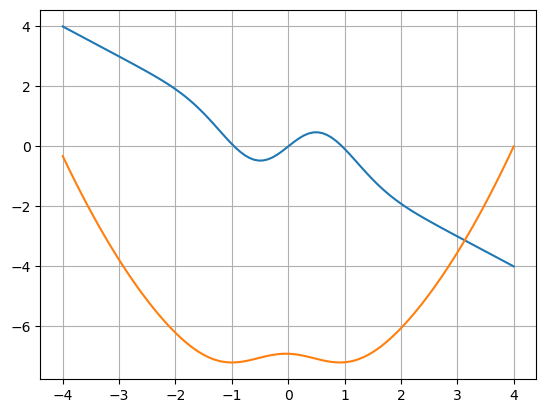

In [152]:
import numpy as np
import matplotlib.pyplot as plt

testx = np.linspace(-4,4,100)
gradient = 10*np.exp(-testx**2)*testx/4-testx #EQ
#gradient = 10*np.exp(-np.abs(testx))*np.sign(testx)/4-testx #exponential
plt.plot(testx,gradient)
plt.plot(testx,-np.cumsum(gradient)*(testx[1]-testx[0]))
plt.grid()